 # **Modelos supervisados: Árbol de Decisión para Clasificación con `sklearn`**


<p>
En este cuaderno, presentamos cómo funcionan los <b>árboles de decisión en problemas de clasificación</b>.
<br>
<br>
Los árboles de decisión en clasificación se utilizan para predecir variables respuesta categóricas. Los métodos de machine learning basados en árboles engloban a un conjunto de técnicas supervisadas no paramétricas que consiguen segmentar el espacio muestral en regiones más pequeñas.
<br>
<br>
La principal implementación de árboles de decisión en Python está disponible en la librería <code>scikit-learn</code> a través de las clases <code>DecisionTreeClassifier</code> y <code>DecisionTreeRegressor</code>.
<br>
<br>
Como criterio de selección de las divisiones óptimas existen varias alternativas, todas ellas con el objetivo de encontrar nodos lo más puros/homogéneos posible.
<br>
<br>
Las criterios para medir la pureza de los nodos más empleadas son:

- **Índice Gini**: cuantifica la varianza total en el conjunto de las $n$ clases del nodo. Cuando Gini es 0, significa que ese nodo es totalmente puro. Por el contrario, si la frecuencia de cada clase es la misma, el valor del Índice Gini alcanza el valor máximo de 0.5. La impureza se refiere a cómo de mezcladas están las clases en cada nodo.
<br>
<br>

$$G = 1- \sum_{i=1}^n ({p}_{i})^2$$
<br>

<p>
Donde $p_i$ representa la proporción de observaciones del nodo que pertenecen a
la clase $i$.

- **Entropía**: es una forma de cuantificar el desorden de un sistema. En el caso de los nodos, el desorden se corresponde con la impureza. Si un nodo es puro, contiene únicamente observaciones de una clase, su entropía es 0. Por el contrario, si la frecuencia de cada clase es la misma, el valor de la entropía alcanza el valor máximo de 1.
<br>
<br>

$$ H = \sum_{i=1}^n -{p}_{i} \ log({p}_{i}) $$
<br>

Análicemos el siguiente ejemplo:

<p>
<img src="https://github.com/cristiandarioortegayubro/BDS/blob/main/images/Arbol-001.png?raw=true" width="280">
</p>

<p>
El Gini del nodo superior sería: $1-(1/4)^2-(3/4)^2 = 0.375$. Si el criterio para medir la pureza de la división fuera la Entropía el cálculo sería: $-1/4\log_{2}(1/4)- 3/4 \log _{2}(3/4) = 0,8112$
<br>
<br>
📊 Graficamente la Entropía o pureza del nodo se puede visualizar del siguiente modo:


<p>
<img src="https://github.com/cristiandarioortegayubro/BDS/blob/main/images/Arbol-002.png?raw=true" width="300">
</p>

## **Bibliotecas**

### Preparación del entorno

Se importan `pandas` y `numpy`, las dos bibliotecas que sostienen el trabajo numérico del cuaderno. `pandas` permite organizar y transformar los datos en tablas, mientras que `numpy` aporta funciones matemáticas que se usarán, entre otras cosas, para calcular la entropía. Estas celdas no generan una salida visible: su función es dejar disponibles los nombres `pd` y `np` para los pasos siguientes.

In [51]:
# Operaciones matemáticas y estadísticas
import pandas as pd
import numpy as np

A continuación se cargan las herramientas de visualización de Plotly. Se utilizarán para explorar la relación entre variables antes de entrenar el modelo. En los gráficos conviene observar si las clases se separan de forma clara o si se superponen, ya que esa estructura anticipa la dificultad del problema de clasificación.

In [52]:
# Visualización
import plotly.express as px
import plotly.graph_objs as go

## **Conjunto de Datos**

<p>
El conjunto de datos <code>Carseats</code>, original del paquete de R <code>ISLR</code> y accesible en Python a través de <code>statsmodels.datasets.get_rdataset</code>, contiene información sobre la venta de sillas infantiles en 400 tiendas distintas.
<br>
<br>
Para cada una de las 400 tiendas se han registrado 11 variables. Se pretende generar un modelo de clasificación que permita predecir si una tienda tiene ventas altas (<code>Sales</code> $>$ 9) o bajas (<code>Sales</code> $<=$ 9) en función de todas las variables disponibles.

### Carga e inspección inicial

El conjunto `Carseats` se descarga mediante `statsmodels` y su tabla principal se guarda en `datos`. La impresión de la documentación permite verificar el significado y la unidad de cada variable antes de transformarla. En la salida, conviene identificar cuál es la variable objetivo original (`Sales`) y cuáles son las variables predictoras disponibles.

In [53]:
import statsmodels.api as sm
carseats = sm.datasets.get_rdataset("Carseats", "ISLR")
datos = carseats.data
print(carseats.__doc__)

======== ===============
Carseats R Documentation
======== ===============

Sales of Child Car Seats
------------------------

Description
~~~~~~~~~~~

A simulated data set containing sales of child car seats at 400
different stores.

Usage
~~~~~

.. code:: R

   Carseats

Format
~~~~~~

A data frame with 400 observations on the following 11 variables.

``Sales``
   Unit sales (in thousands) at each location

``CompPrice``
   Price charged by competitor at each location

``Income``
   Community income level (in thousands of dollars)

``Advertising``
   Local advertising budget for company at each location (in thousands
   of dollars)

``Population``
   Population size in region (in thousands)

``Price``
   Price company charges for car seats at each site

``ShelveLoc``
   A factor with levels ``Bad``, ``Good`` and ``Medium`` indicating the
   quality of the shelving location for the car seats at each site

``Age``
   Average age of the local population

``Education``
   Education level

Las siguientes inspecciones ofrecen dos vistas complementarias: `head()` muestra ejemplos concretos de filas, mientras que `info()` resume tipos de datos, cantidad de valores no nulos y uso de memoria. Hay que comprobar que las columnas categóricas estén reconocidas como texto y que no existan valores faltantes que requieran un tratamiento adicional.

In [54]:
datos.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [55]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


<p>
Como <code>Sales</code> es una variable continua y el objetivo del estudio es clasificar las tiendas según si venden mucho o poco, se crea una nueva variable dicotómica (<code>'altas'</code>, <code>'bajas'</code>) llamada <code>sales</code>.

In [56]:
datos['sales'] = datos.Sales.apply(lambda x: "altas" if x > 9 else "bajas")
#datos['sales'] = np.where(datos.Sales > 9, "altas", "bajas")

<p>
Una vez creada la nueva variable respuesta categórica se descarta la original mediante el método <code>drop()</code>.

In [57]:
datos = datos.drop(columns = 'Sales')

### Comprobaciones y muestra de trabajo

Después de crear la clase objetivo y eliminar `Sales`, se comprueba el resultado de la transformación. `head()` permite verificar las primeras filas, `len()` confirma el número total de observaciones y `data_10` conserva una muestra pequeña para reproducir manualmente la lógica de las primeras divisiones de un árbol.

In [58]:
datos.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
0,138,73,11,276,120,Bad,42,17,Yes,Yes,altas
1,111,48,16,260,83,Good,65,10,Yes,Yes,altas
2,113,35,10,269,80,Medium,59,12,Yes,Yes,altas
3,117,100,4,466,97,Medium,55,14,Yes,Yes,bajas
4,141,64,3,340,128,Bad,38,13,Yes,No,bajas


In [59]:
len(datos)

400

In [60]:
data_10 = datos.head(10)
data_10

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
0,138,73,11,276,120,Bad,42,17,Yes,Yes,altas
1,111,48,16,260,83,Good,65,10,Yes,Yes,altas
2,113,35,10,269,80,Medium,59,12,Yes,Yes,altas
3,117,100,4,466,97,Medium,55,14,Yes,Yes,bajas
4,141,64,3,340,128,Bad,38,13,Yes,No,bajas
5,124,113,13,501,72,Bad,78,16,No,Yes,altas
6,115,105,0,45,108,Medium,71,15,Yes,No,bajas
7,136,81,15,425,120,Good,67,10,Yes,Yes,altas
8,132,110,0,108,124,Medium,76,10,No,No,bajas
9,132,113,0,131,124,Medium,76,17,No,Yes,bajas


### Entropía y evaluación manual de divisiones

La función `log2` evita el caso indefinido de calcular el logaritmo de cero. La función `entropy` cuenta las dos clases, calcula sus proporciones y aplica la fórmula de entropía. El valor resultante mide impureza: **0** indica que todas las observaciones pertenecen a una sola clase; valores mayores indican una mezcla más equilibrada. Aplicarla primero sobre diez casos facilita interpretar los cálculos posteriores.

In [61]:
def log2(x):
  v = 0 if x == 0 else np.log2(x)
  return v

def entropy(var):
  cl1 = np.sum(var == 'bajas')
  cl2 = np.sum(var == 'altas')
  p1 = cl1 / len(var)
  p2 = cl2 / len(var)
  h = -p1 * log2(p1) - p2 * log2(p2)
  return h

In [62]:
print(entropy(data_10.sales))

1.0


Las consultas siguientes simulan posibles reglas de partición. Primero se separan las tiendas según `Price > 90` y se calcula la entropía de cada grupo; luego cada rama se subdivide según `Advertising > 10`. Al comparar las salidas, interesa buscar ramas con entropía baja, porque representan grupos más puros y, por tanto, reglas potencialmente útiles para clasificar.

In [63]:
d_p100 = data_10.query("Price > 90")
d_p100

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
0,138,73,11,276,120,Bad,42,17,Yes,Yes,altas
3,117,100,4,466,97,Medium,55,14,Yes,Yes,bajas
4,141,64,3,340,128,Bad,38,13,Yes,No,bajas
6,115,105,0,45,108,Medium,71,15,Yes,No,bajas
7,136,81,15,425,120,Good,67,10,Yes,Yes,altas
8,132,110,0,108,124,Medium,76,10,No,No,bajas
9,132,113,0,131,124,Medium,76,17,No,Yes,bajas


In [64]:
entropy(d_p100.sales)

0.863120568566631

In [65]:
d_p100_ = data_10.query("Price <= 90")
d_p100_

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
1,111,48,16,260,83,Good,65,10,Yes,Yes,altas
2,113,35,10,269,80,Medium,59,12,Yes,Yes,altas
5,124,113,13,501,72,Bad,78,16,No,Yes,altas


In [66]:
entropy(d_p100_.sales)

-0.0

In [67]:
d_p100.query("Advertising > 10")

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
0,138,73,11,276,120,Bad,42,17,Yes,Yes,altas
7,136,81,15,425,120,Good,67,10,Yes,Yes,altas


In [68]:
entropy(d_p100.query("Advertising > 10").sales), entropy(d_p100.query("Advertising <= 10").sales)

(-0.0, -0.0)

In [69]:
entropy(d_p100_.query("Advertising > 10").sales), entropy(d_p100_.query("Advertising <= 10").sales)

(-0.0, -0.0)

In [70]:
d_p100_.query("Advertising > 10").sales

1    altas
5    altas
Name: sales, dtype: object

La consulta sobre el conjunto completo recupera las observaciones que cumplen simultáneamente dos condiciones. Sirve para trasladar el ejercicio manual de la muestra de diez filas a todos los datos y comprobar cuántos casos quedarían en esa región del árbol. En la tabla resultante deben revisarse especialmente las clases de `sales` y la homogeneidad del subconjunto.

In [71]:
datos.query("Price <= 90 and Advertising > 10")

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,sales
1,111,48,16,260,83,Good,65,10,Yes,Yes,altas
5,124,113,13,501,72,Bad,78,16,No,Yes,altas
13,115,28,11,29,86,Good,53,18,Yes,Yes,altas
46,127,90,14,16,70,Medium,48,15,No,Yes,altas
77,118,71,12,44,89,Medium,67,18,No,Yes,bajas
80,113,100,16,353,79,Bad,68,11,Yes,Yes,bajas
130,94,84,13,497,77,Medium,51,12,Yes,Yes,bajas
149,121,120,13,140,87,Medium,56,11,Yes,Yes,altas
169,104,41,15,492,77,Good,73,18,Yes,Yes,altas
171,93,106,12,416,55,Medium,75,15,Yes,Yes,altas


## **Análisis Gráfico**

### Exploración de relaciones entre variables

Los diagramas de dispersión comparan `Price` y `Advertising`. La clase de ventas se distingue mediante color. Hay que observar si aparecen agrupamientos, solapamientos o regiones donde una clase sea más frecuente, patrones que un árbol podría convertir en reglas de decisión.

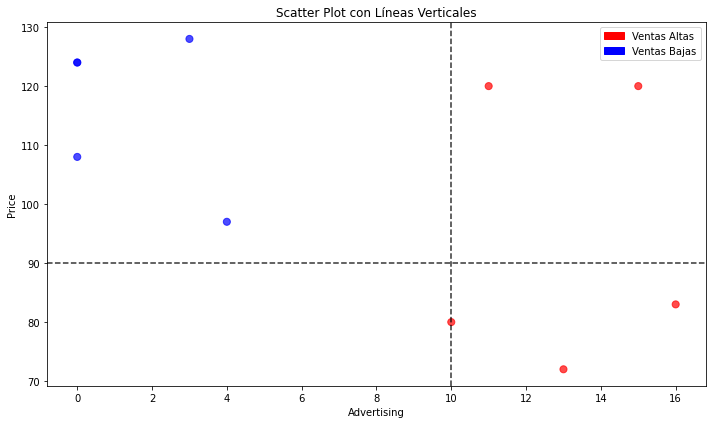

In [72]:
import matplotlib.pyplot as plt

df = data_10

fig, ax = plt.subplots(figsize=(10, 6))

# Crear colores específicos para cada clase
colors = df['sales'].map({'altas': 'red', 'bajas': 'blue'})

# Crear el scatter plot
ax.scatter(x=df['Advertising'], y=df['Price'], c=colors, alpha=0.7, s=50)

ax.axvline(x=10, color='black', linestyle='--', alpha=0.8
           )

ax.axhline(y=90, color='black', linestyle='--', alpha=0.8 
           )

# Personalizar el gráfico
ax.set_xlabel('Advertising')
ax.set_ylabel('Price')
ax.set_title('Scatter Plot con Líneas Verticales')

# Crear leyenda manual para los colores
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Ventas Altas')
blue_patch = mpatches.Patch(color='blue', label='Ventas Bajas')
ax.legend(handles=[red_patch, blue_patch] + ax.get_legend_handles_labels()[0])

plt.tight_layout()
plt.show()

En el caso de loas pocas observaciones vemos que la clasificación es perfecta. Ya lo mostraba la entropía y ahora lo vemos gráficamente. Sin embargo si tomamos esos parámetros para todas las observaciones ya no funciona.

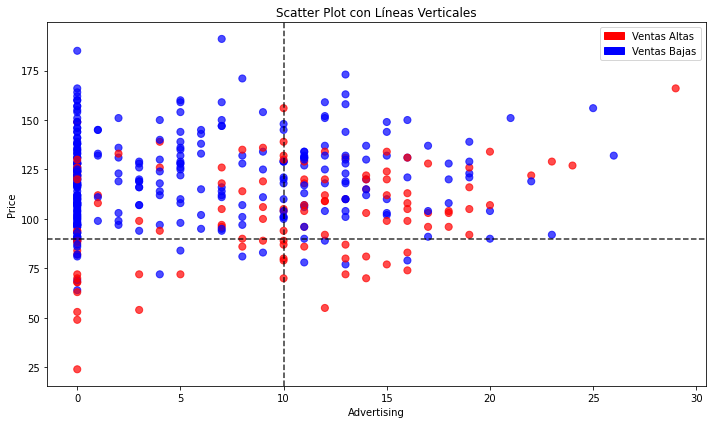

In [73]:
import matplotlib.pyplot as plt

df = datos

fig, ax = plt.subplots(figsize=(10, 6))

# Crear colores específicos para cada clase
colors = df['sales'].map({'altas': 'red', 'bajas': 'blue'})

# Crear el scatter plot
ax.scatter(x=df['Advertising'], y=df['Price'], c=colors, alpha=0.7, s=50)

ax.axvline(x=10, color='black', linestyle='--', alpha=0.8
           )

ax.axhline(y=90, color='black', linestyle='--', alpha=0.8 
           )

# Personalizar el gráfico
ax.set_xlabel('Advertising')
ax.set_ylabel('Price')
ax.set_title('Scatter Plot con Líneas Verticales')

# Crear leyenda manual para los colores
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Ventas Altas')
blue_patch = mpatches.Patch(color='blue', label='Ventas Bajas')
ax.legend(handles=[red_patch, blue_patch] + ax.get_legend_handles_labels()[0])

plt.tight_layout()
plt.show()

 ## **División del conjunto de datos**

Se separan las variables predictoras (`X`) de la variable objetivo (`y`). Esta distinción es necesaria porque `scikit-learn` recibe ambos objetos por separado: `X` contiene la información con la que se aprende y `y` contiene la clase que el modelo debe predecir. La celda no muestra salida; prepara los datos para el preprocesamiento.

In [74]:
X = datos.drop(columns=['sales'])
y = datos['sales']

 ## **División del conjunto de entrenamiento y prueba**

### Separación entre entrenamiento y prueba

`train_test_split` reserva una parte de los datos para evaluar el modelo con observaciones no utilizadas durante el ajuste. La semilla fija hace reproducible la partición y la estratificación, si está configurada, mantiene proporciones similares de las clases. El resultado son cuatro objetos: predictores y etiquetas para entrenamiento, y sus equivalentes para prueba.

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=123)

 ## **Preprocesamiento de variables categóricas con `sklearn`**

Se importan las piezas necesarias para transformar variables categóricas sin alterar las numéricas. El selector identifica columnas por tipo, `OneHotEncoder` convierte cada categoría en indicadores binarios y `ColumnTransformer` coordina ambas rutas. Este esquema evita asignar un orden artificial a categorías nominales.

In [76]:
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

<p>
Primero se identifica el nombre de las columnas categóricas y numéricas. El resultado es una <code>lista</code>.

In [77]:
categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(X)

In [78]:
categorical_columns

['ShelveLoc', 'Urban', 'US']

In [79]:
#categorical_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
#categorical_columns

In [80]:
numerical_columns_selector = selector(dtype_include=[int,float])
numerical_columns = numerical_columns_selector(X)

<p>
Luego se aplica <b>one-hot-encoding</b> solo a las columnas categóricas. El parámetro <code>remainder</code> en <code>ColumnTransformer</code> determina cómo se deben manejar las columnas que no son seleccionadas o transformadas por los transformadores.
<br>
<br>
De forma predeterminada, el parámetro <code>remainder</code> está configurado en <code>drop</code>, lo que significa que cualquier columna restante que no esté especificada en los transformadores se eliminará.
<br>
<br>
Alternativamente, puedes establecer <code>remainder='passthrough'</code> para incluir las columnas restantes en la salida sin aplicar ninguna transformación. Esto es útil cuando se necesitan mantener ciertas columnas sin cambios, como en este caso las columnas numéricas.

In [81]:
preprocessor = ColumnTransformer(
                    [('one-hot-encoding',
                      OneHotEncoder(handle_unknown='ignore',sparse=False),
                      categorical_columns)],                    
                    remainder='passthrough')

<p>
Una vez que se ha definido el objeto <code>ColumnTransformer</code>, con el método <code>fit_transform()</code> se aplican las tranformaciones al conjunto de datos <code>X</code>.

In [82]:
X_encoded = preprocessor.fit_transform(X_train)
X_encoded.shape

(300, 14)

<p>
El resultado devuelto es un <code>numpy array</code>, por lo que se pierden los nombres de las columnas. Suele ser interesante poder inspeccionar cómo queda el conjunto de datos tras el preprocesado en formato <code>DataFrame</code>.
<br>
<br>
Por defecto, <code>OneHotEncoder</code> ordena las nuevas columnas de izquierda a derecha por orden alfabético.

Convertir el `numpy array` en `dataframe` y añadir el nombre de las columnas.

El codificador genera los nombres de las nuevas columnas binarias. Después, esos nombres se combinan con los de las variables numéricas para reconstruir un `DataFrame` legible. En la salida se debe comprobar que cada categoría tenga su indicador y que el número de etiquetas coincida con las columnas de `X_encoded`.

In [83]:
columns_endoded = preprocessor.named_transformers_['one-hot-encoding'].get_feature_names_out(categorical_columns)
columns_endoded

array(['ShelveLoc_Bad', 'ShelveLoc_Good', 'ShelveLoc_Medium', 'Urban_No',
       'Urban_Yes', 'US_No', 'US_Yes'], dtype=object)

In [84]:
labels = np.concatenate([columns_endoded,numerical_columns])
X_transformed = pd.DataFrame(X_encoded, columns=labels)
X_transformed.head()

,ShelveLoc_Bad,ShelveLoc_Good,ShelveLoc_Medium,Urban_No,Urban_Yes,US_No,US_Yes,CompPrice,Income,Advertising,Population,Price,Age,Education
0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,128.0,39.0,12.0,356.0,118.0,71.0,10.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,118.0,83.0,13.0,276.0,104.0,75.0,10.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,110.0,119.0,0.0,384.0,97.0,72.0,14.0
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,132.0,68.0,0.0,264.0,123.0,34.0,11.0
4,0.0,0.0,1.0,0.0,1.0,1.0,0.0,122.0,35.0,2.0,393.0,136.0,62.0,18.0


In [85]:
X_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ShelveLoc_Bad     300 non-null    float64
 1   ShelveLoc_Good    300 non-null    float64
 2   ShelveLoc_Medium  300 non-null    float64
 3   Urban_No          300 non-null    float64
 4   Urban_Yes         300 non-null    float64
 5   US_No             300 non-null    float64
 6   US_Yes            300 non-null    float64
 7   CompPrice         300 non-null    float64
 8   Income            300 non-null    float64
 9   Advertising       300 non-null    float64
 10  Population        300 non-null    float64
 11  Price             300 non-null    float64
 12  Age               300 non-null    float64
 13  Education         300 non-null    float64
dtypes: float64(14)
memory usage: 32.9 KB


 ## **Ajuste y evaluación del modelo con `sklearn`**

Documentación [Árbol de Decisión para Clasificación](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

Se importa `DecisionTreeClassifier`, el estimador que construirá reglas jerárquicas de clasificación. La importación no entrena todavía ningún modelo; únicamente deja disponible la clase con la que se definirá su configuración.

In [86]:
from sklearn.tree import DecisionTreeClassifier

<p>
En este ejemplo, se crea un de árbol de decisión para clasificación mediante la clase <code>DecisionTreeClassifier()</code> de <code>scikit_learn</code>. Luego, se ajusta el modelo a los datos de entrenamiento utilizando el método <code>fit()</code>, donde <code>X_train</code> representa las variabres predictoras de entrenamiento e </code>y_train</code> es la variable objetivo de entrenamiento.
<br>
<br>
Los hiperparámetros utilizados son:

- `max_depth = 2`: establece la profundidad máxima del árbol de decisión. Limita el número de niveles y nodos en el árbol. En este caso, el árbol tendrá una profundidad máxima de 2. Se estableció en este valor solo a fines pedagógicos para mostrar el funcionamiento del árbol.

- `criterion = 'entropy'`: especifica el criterio utilizado para medir la calidad de una división durante la construcción del árbol de decisión. El criterio de `'entropy'` utiliza el concepto de entropía de la información para medir la impureza de los nodos. Por defecto, el valor de este hiper-parámetro es `'gini'`.

- `random_state = 123`: establece la semilla aleatoria para garantizar la reproducibilidad. Al establecer el estado aleatorio en un valor específico (123 en este caso), el generador de números aleatorios producirá la misma secuencia de números aleatorios cada vez que ejecutes el código. Esto asegura que tus resultados sean consistentes y reproducibles.

In [89]:
model_dt = make_pipeline(preprocessor, DecisionTreeClassifier(max_depth = 10,
                                  criterion = 'entropy',
                                  random_state = 123
                                  ))

In [90]:
model_dt.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one-hot-encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['ShelveLoc', 'Urban',
                                                   'US'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                        random_state=123))])

<p>
Una vez ajustado el modelo, se pueden realizar predicciones en los datos de prueba utilizando el método <code>predict()</code> y evaluarlo con <code>score()</code>.

In [91]:
model_dt.predict(X_test)

array(['altas', 'bajas', 'altas', 'altas', 'bajas', 'bajas', 'bajas',
       'altas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'altas',
       'altas', 'bajas', 'altas', 'bajas', 'bajas', 'bajas', 'bajas',
       'bajas', 'bajas', 'altas', 'bajas', 'bajas', 'altas', 'bajas',
       'bajas', 'bajas', 'altas', 'bajas', 'bajas', 'altas', 'bajas',
       'bajas', 'bajas', 'bajas', 'bajas', 'altas', 'bajas', 'bajas',
       'bajas', 'altas', 'bajas', 'altas', 'altas', 'bajas', 'bajas',
       'bajas', 'altas', 'bajas', 'altas', 'altas', 'bajas', 'bajas',
       'altas', 'bajas', 'bajas', 'altas', 'bajas', 'bajas', 'bajas',
       'bajas', 'altas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas',
       'bajas', 'bajas', 'bajas', 'bajas', 'altas', 'bajas', 'bajas',
       'altas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas',
       'bajas', 'bajas', 'altas', 'altas', 'bajas', 'bajas', 'altas',
       'bajas', 'altas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas',
       'altas', 'baj

In [92]:
y_test.values

array(['altas', 'altas', 'altas', 'bajas', 'bajas', 'altas', 'bajas',
       'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas',
       'altas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'bajas',
       'bajas', 'altas', 'altas', 'bajas', 'bajas', 'altas', 'bajas',
       'altas', 'bajas', 'altas', 'bajas', 'bajas', 'bajas', 'altas',
       'bajas', 'bajas', 'bajas', 'bajas', 'bajas', 'altas', 'bajas',
       'bajas', 'altas', 'bajas', 'bajas', 'altas', 'altas', 'bajas',
       'bajas', 'bajas', 'bajas', 'bajas', 'altas', 'bajas', 'altas',
       'altas', 'bajas', 'bajas', 'altas', 'bajas', 'bajas', 'bajas',
       'bajas', 'altas', 'bajas', 'altas', 'altas', 'bajas', 'altas',
       'bajas', 'bajas', 'bajas', 'bajas', 'altas', 'bajas', 'bajas',
       'altas', 'altas', 'bajas', 'altas', 'bajas', 'bajas', 'bajas',
       'altas', 'altas', 'altas', 'altas', 'bajas', 'bajas', 'altas',
       'bajas', 'altas', 'altas', 'altas', 'bajas', 'bajas', 'bajas',
       'altas', 'baj

In [93]:
model_dt.score(X_test, y_test)

0.74

<p>
La <b>exactitud</b> o <b>accuracy</b> del modelo es 0.74. Es decir, el modelo es capaz de predecir correctamente un 74 % de las observaciones del conjunto de prueba.

### Modelo de referencia y matrices de confusión

Se ajusta una regresión logística como punto de comparación. Su exactitud permite juzgar si la estructura más flexible del árbol aporta una mejora real. Luego se calculan matrices de confusión para ambos modelos, tanto en prueba como en entrenamiento. Las filas representan clases reales y las columnas, clases predichas; la diagonal reúne los aciertos. Una diferencia grande entre entrenamiento y prueba puede advertir sobreajuste.

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
preprocessor2 = ColumnTransformer(
                    [('one-hot-encoding',
                      OneHotEncoder(handle_unknown='ignore',sparse=False),
                      categorical_columns),
                    ('escalado', StandardScaler(), numerical_columns)]
                    )

model_lr = make_pipeline(preprocessor2, LogisticRegression(random_state = 123, max_iter = 1000)).fit(X_train, y_train)
model_lr.score(X_test, y_test)

0.86

In [110]:
from sklearn.metrics import confusion_matrix
def matriz_confusion(y_test, predict):
    matriz_confusion = confusion_matrix(y_test,predict)
    return pd.DataFrame(
        matriz_confusion,
        index=["Real 0", "Real 1"],
        columns=["bajas ventas", "altas ventas"]
    )
    
display(matriz_confusion(y_test, model_dt.predict(X_test)),matriz_confusion(y_test, model_lr.predict(X_test)))

,bajas ventas,altas ventas
Real 0,19,17
Real 1,9,55


,bajas ventas,altas ventas
Real 0,26,10
Real 1,4,60


In [112]:
display(matriz_confusion(y_train, model_dt.predict(X_train)),
        matriz_confusion(y_train, model_lr.predict(X_train)))

,bajas ventas,altas ventas
Real 0,77,0
Real 1,0,223


,bajas ventas,altas ventas
Real 0,64,13
Real 1,8,215


### Evaluación mediante validación cruzada

La validación cruzada repite el entrenamiento en cinco particiones distintas y evalúa cada versión en el bloque que quedó fuera. Este procedimiento reduce la dependencia de una única separación entrenamiento-prueba. `cv_results` contiene los puntajes de cada repetición; su media resume el rendimiento esperado y su desviación estándar muestra cuánto cambia entre particiones.

In [102]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(model_dt, X, y, cv = 5)
cv_results

{'fit_time': array([0.00938058, 0.00926828, 0.00899267, 0.00593519, 0.00593114]),
 'score_time': array([0.00481796, 0.00478959, 0.00369954, 0.00287533, 0.00307488]),
 'test_score': array([0.775 , 0.7875, 0.775 , 0.7875, 0.725 ])}

In [103]:
scores = cv_results["test_score"]
print("")
print(f"La accuracy mediante cross-validation es: {scores.mean():.3f} ± {scores.std():.3f}")


La accuracy mediante cross-validation es: 0.770 ± 0.023


 ## **Visualización del árbol de decisión**

Documentación [Plot Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)

La representación gráfica traduce el modelo ajustado a reglas legibles. Antes del árbol se informan su profundidad y cantidad de hojas, dos indicadores directos de complejidad. En cada nodo conviene leer la condición de corte, la cantidad de observaciones, la impureza y la clase predominante; el recorrido comienza en la raíz y continúa por la rama cuya condición cumpla el caso analizado.

Profundidad del árbol: 10
Número de nodos terminales: 32


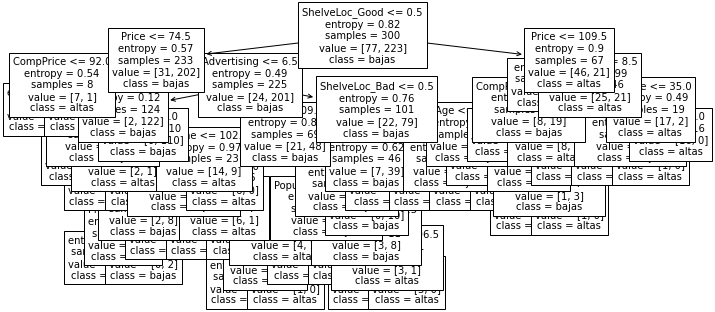

In [126]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
print(f"Profundidad del árbol: {model_dt[1].get_depth()}")
print(f"Número de nodos terminales: {model_dt[1].get_n_leaves()}")

plot = plot_tree(
            decision_tree = model_dt[1],
            feature_names = labels.tolist(),
            class_names   = ['altas','bajas'],
            filled = False,
            impurity      = True,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

<p>
El árbol de decisión generado se divide en función de las variables <code>ShelveLoc_Good</code> y <code>Price</code>. La raíz del árbol es la primera división que se realiza. A partir de ahí, cada nodo interno representa una pregunta o condición sobre las características y las ramas salientes representan las diferentes respuestas a esa pregunta.
<br>
<br>
El árbol de decisión se puede interpretar de la siguiente manera:

- En la raíz del árbol, se realiza la primera pregunta: "¿Es `ShelveLoc_Good` menor o igual a 0.5?"
 - Si es verdadero, se sigue por la rama izquierda, y el árbol realiza una segunda pregunta: "¿Es `Price` menor o igual a 74.5?"
 - Si es verdadero, se llega a una hoja del árbol donde se predice que las ventas son `altas`.
 - Si es falso, se llega a otra hoja del árbol donde se predice que las ventas son `bajas`.
 - Si es falso, se sigue por la rama derecha, y el árbol realizan una segunda pregunta: "¿Es `Price` menor o igual a 109.5?"
 - Si es verdadero, se llega a una hoja del árbol donde se predice que las ventas son `altas`.
 - Si es falso, se llega a otra hoja del árbol donde se predice que las ventas son `altas`.

<br>
<p>
Las hojas del árbol (nodos terminales) representan las predicciones finales para cada rama. En este caso, las hojas están etiquetadas como <code>altas</code> o <code>bajas</code>, según la clasificación prevista para cada combinación de variables.
<br>
<br>
Teniendo en cuenta el siguiente ejemplo se realiza la clasifición de ventas, suponga la sucursal en la posición 0 del conjunto de prueba que tiene las siguientes características:

### Seguimiento de una predicción individual

Se inspecciona la primera observación de prueba para recorrer manualmente sus valores por las reglas del árbol. Después se comparan la predicción del modelo y la etiqueta real. Esta verificación conecta la estructura visual del árbol con una decisión concreta y permite detectar si ese caso fue clasificado correctamente.

In [113]:
X_test.iloc[0,:]

CompPrice       115
Income           62
Advertising      11
Population      289
Price           129
ShelveLoc      Good
Age              56
Education        16
Urban            No
US              Yes
Name: 234, dtype: object

<p>
Para esta sucursal <code>ShelveLoc_Good</code> es 1 (esto significa que el producto tiene una buena ubicación en la tienda), por lo tanto, mayor a 0.5, por lo tanto se sigue a la rama derecha y acá el precio es 129, el cual es mayor al umbral de 109.5, se sigue por la rama derecha y por lo tanto se predice que la venta en esa sucursal son <code>altas</code>.

In [114]:
model_dt.predict(X_test)[0]

'altas'

In [115]:
y_test[0]

'altas'

<p>
Los hiperparámetros <code>min_sample_leaf</code> y <code>min_samples_split</code> del algoritmo <code>DecisionTreeClassifier</code> permiten controlar la complejidad del árbol de decisión y evitar divisiones que puedan conducir a nodos con muy pocas muestras, lo que podría resultar en un <b>sobreajuste</b>.
<br>
<br>
Al aumentar los valores de estos hiperparámetros, se obtendrá un árbol de decisión más generalizado y menos complejo.


- `min_samples_leaf` especifica el número mínimo de muestras requeridas para que un nodo sea considerado una hoja (nodo terminal) en el árbol de decisión. Si el número de muestras en un nodo es menor que `min_samples_leaf`, no se realizará una división en ese nodo y se convertirá en una hoja. Este parámetro ayuda a evitar divisiones que produzcan hojas con muy pocas muestras, lo que puede ser útil para evitar sobreajuste. Garantiza un número mínimo de muestras en una hoja terminal.

- `min_samples_split` especifica el número mínimo de muestras requeridas para que se realice una división en un nodo. Si el número de muestras en un nodo es menor que `min_samples_split`, no se realizará ninguna división en ese nodo, y se convertirá en una hoja. Este parámetro controla la cantidad mínima de muestras necesarias para que un nodo sea elegible para realizar una división.

<br>
<p>
Comprobemos el efecto de incorporar el parámetro <code>min_samples_leaf</code>:

In [136]:
model_dt_2 = make_pipeline(preprocessor, DecisionTreeClassifier(max_depth = 10,
                                    min_samples_leaf = 10,
                                  criterion = 'entropy',
                                  random_state = 123
                                  )).fit(X_train,y_train)



El segundo árbol introduce un mínimo de observaciones por hoja. Esta restricción evita ramas apoyadas en muy pocos casos y suele reducir el sobreajuste. La validación cruzada permite comparar su capacidad de generalización con la del primer árbol; no basta con mirar una sola partición para decidir cuál configuración es mejor.

In [140]:
display(matriz_confusion(y_train, model_dt_2.predict(X_train)),matriz_confusion(y_test, model_dt_2.predict(X_test)))

,bajas ventas,altas ventas
Real 0,62,15
Real 1,13,210


,bajas ventas,altas ventas
Real 0,19,17
Real 1,9,55


In [137]:
cv_results = cross_validate(model_dt_2, X, y)
cv_results

{'fit_time': array([0.00603747, 0.00534773, 0.005481  , 0.00552201, 0.00524616]),
 'score_time': array([0.0030787 , 0.00298905, 0.00273705, 0.00284481, 0.00323462]),
 'test_score': array([0.8125, 0.775 , 0.8   , 0.7625, 0.75  ])}

In [134]:
scores = cv_results["test_score"]
print("")
print(f"La accuracy mediante cross-validation es: {scores.mean():.3f} ± {scores.std():.3f}")


La accuracy mediante cross-validation es: 0.780 ± 0.023


Finalmente se visualiza el árbol regularizado. Al compararlo con el anterior, deben observarse la profundidad, el número de hojas y la simplicidad de las reglas. Un árbol más compacto puede ser preferible si mantiene un rendimiento similar, porque suele ser más estable e interpretable.

Profundidad del árbol: 6
Número de nodos terminales: 14


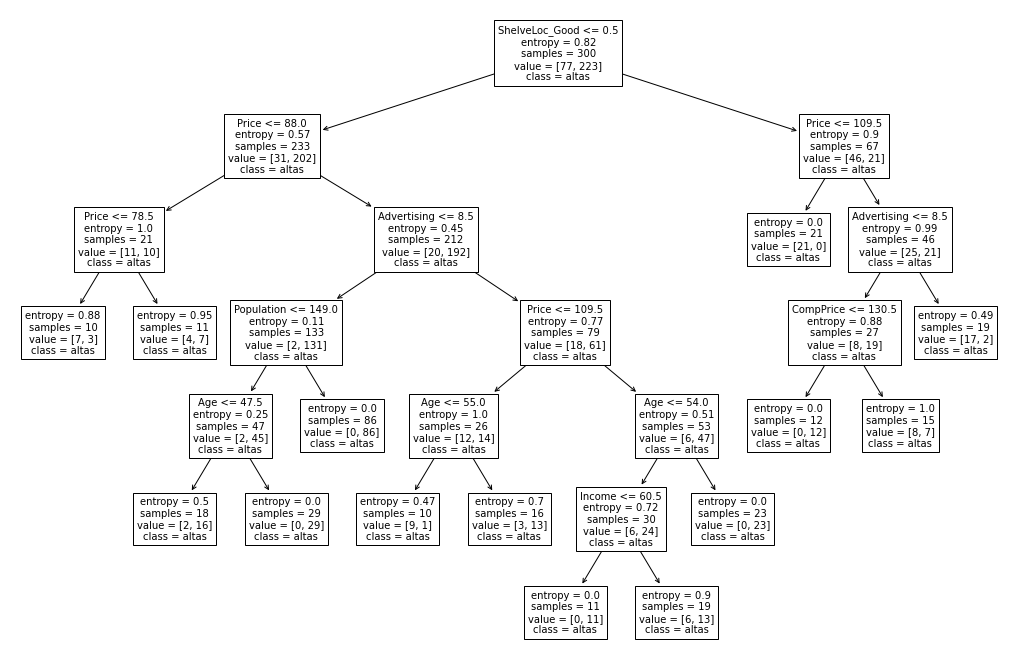

In [135]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 12))
print(f"Profundidad del árbol: {model_dt_2[1].get_depth()}")
print(f"Número de nodos terminales: {model_dt_2[1].get_n_leaves()}")

plot = plot_tree(
            decision_tree = model_dt_2[1],
            feature_names = labels.tolist(),
            class_names   = y,
            filled = False,
            impurity      = True,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

 # **Conclusiones**

<p>
 En este colab nosotros:
<br><br>
 Utilizamos la biblioteca <code>scikit_learn</code> para entrenar un modelo de árbol de decisión en el contexto de un problema de clasificación.
<br>
 Realizamos un análisis del comportamiento del árbol de decisión a través de la generación de un gráfico denominado <code>plot_tee</code>.
